# Olist E-Commerce Analysis
## Notebook 3 — Exploratory Data Analysis

Exploring key business questions:
- How do delivery times affect customer satisfaction?
- Are late orders rated lower?
- Which product categories perform best?
- How does order volume trend over time?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../outputs/olist_clean.csv", parse_dates=['order_purchase_timestamp'])

print(df.shape)
df.head()

(114854, 38)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,delay_days,...,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,...,sao paulo,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,...,sao paulo,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,...,sao paulo,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,...,barreiras,BA,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,...,vianopolis,GO,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0


### Q1: How are customers rating their experience?

review_score
1.0    13117
2.0     3899
3.0     9649
4.0    22150
5.0    66039
Name: count, dtype: int64


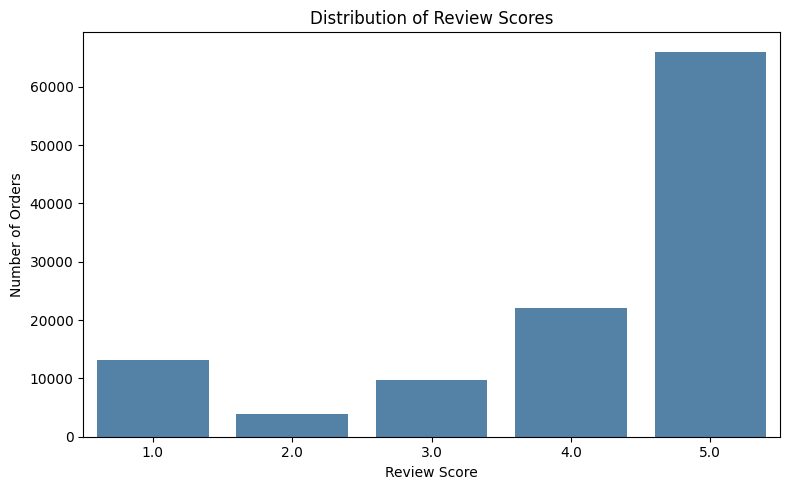

In [4]:
review_counts = df['review_score'].value_counts().sort_index()
print(review_counts)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='review_score', color='steelblue')
plt.title('Distribution of Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('../outputs/review_score_distribution.png')
plt.show()

*Note: Initial chart used a sequential color palette which created visual bias — 
darker bars appeared larger regardless of actual value. Switched to uniform color for honest comparison.*

### Q2: Do late deliveries lead to lower review scores?

In [5]:
avg_score_by_delay = df.groupby(
    pd.cut(df['delay_days'], bins=[-200, -30, -10, 0, 10, 200])
)['review_score'].mean().round(2)

print(avg_score_by_delay)

delay_days
(-200, -30]    4.13
(-30, -10]     4.23
(-10, 0]       4.16
(0, 10]        2.50
(10, 200]      1.71
Name: review_score, dtype: float64


C:\Users\Moi\AppData\Local\Temp\ipykernel_17144\3728461243.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_score_by_delay = df.groupby(


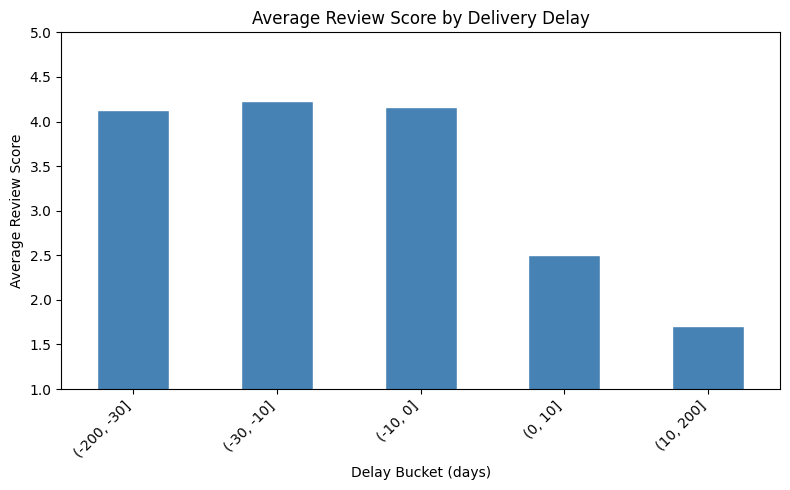

In [6]:
plt.figure(figsize=(8, 5))
avg_score_by_delay.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Average Review Score by Delivery Delay')
plt.xlabel('Delay Bucket (days)')
plt.ylabel('Average Review Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(1, 5)
plt.tight_layout()
plt.savefig('../outputs/review_by_delay.png')
plt.show()

### Finding 1: Late deliveries are the strongest driver of poor reviews.

Orders arriving even slightly late (0-10 days) drop from an average score of 4.16 to 2.50.
Orders arriving 10+ days late average just 1.71 — effectively a 1-2 star experience.
Arriving early has minimal positive impact, suggesting customers are more sensitive to bad surprises than good ones.

### Q3: Which product categories have the most orders?

In [7]:
top_categories = (
    df['product_category_name']
    .value_counts()
    .head(10)
)

print(top_categories)

product_category_name
cama_mesa_banho           11685
beleza_saude               9750
esporte_lazer              8735
moveis_decoracao           8558
informatica_acessorios     7926
utilidades_domesticas      7154
relogios_presentes         6030
telefonia                  4580
ferramentas_jardim         4452
automotivo                 4259
Name: count, dtype: int64


### Translate category names to English

In [8]:
translation = pd.read_csv("../data/raw/product_category_name_translation.csv")

# Merge translation into main df
df = df.merge(translation, on='product_category_name', how='left')

# Check it worked
df[['product_category_name', 'product_category_name_english']].head()

,product_category_name,product_category_name_english
0,utilidades_domesticas,housewares
1,utilidades_domesticas,housewares
2,utilidades_domesticas,housewares
3,perfumaria,perfumery
4,automotivo,auto


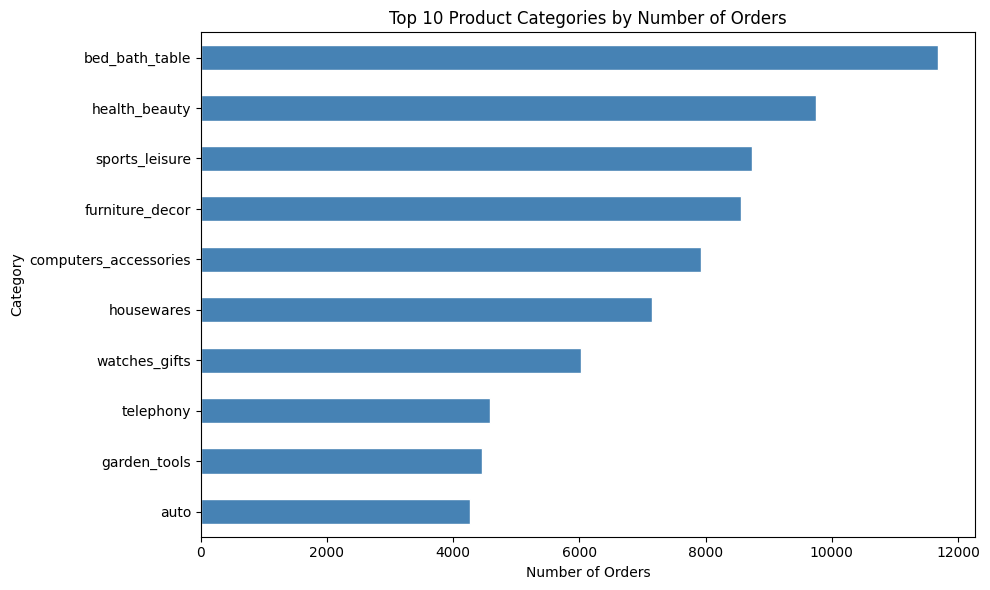

In [9]:
top_categories = (
    df['product_category_name_english']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))
top_categories.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 10 Product Categories by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Category')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/top_categories.png')
plt.show()

### Finding 2: Bed, bath & table is the most ordered category, followed by health & beauty and sports & leisure.
These three categories alone account for a significant share of total orders, suggesting Olist's strength is in everyday home and lifestyle products rather than electronics or automotive.

### Q4: How did order volume trend over time?

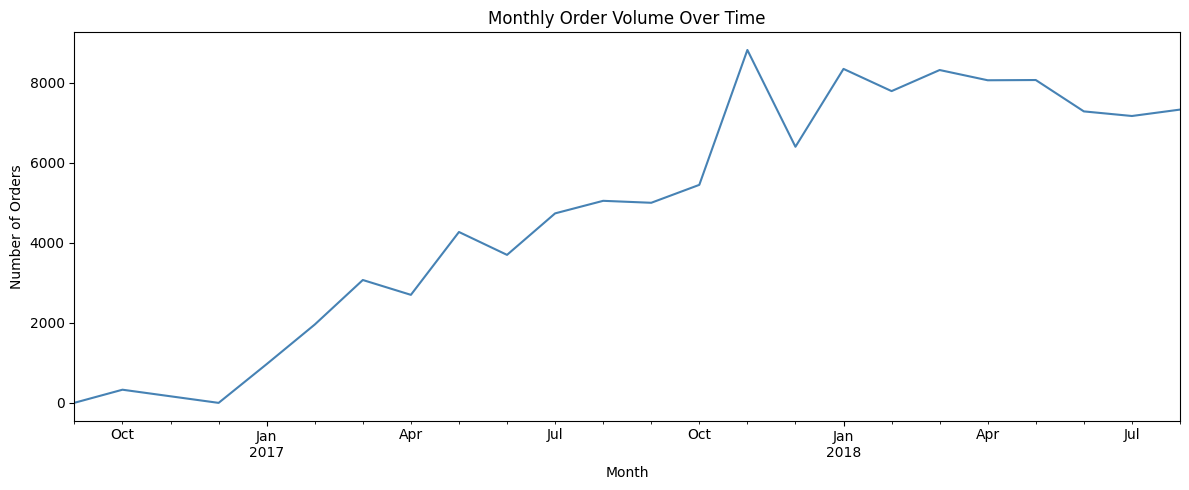

In [10]:
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = df.groupby('order_month').size()

plt.figure(figsize=(12, 5))
monthly_orders.plot(kind='line', color='steelblue')
plt.title('Monthly Order Volume Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('../outputs/monthly_orders.png')
plt.show()

### Finding 3: Olist showed strong growth from late 2016 through 2018, with a clear peak in November 2017 likely driven by Black Friday promotions. Overall trend confirms the platform was in a healthy growth phase during this period.

### Q5: Which product categories have the worst customer satisfaction?

In [11]:
category_satisfaction = (
    df.groupby('product_category_name_english')['review_score']
    .agg(['mean', 'count'])
    .round(2)
    .sort_values('mean', ascending=True)
)

# Only keep categories with enough orders to be meaningful
category_satisfaction = category_satisfaction[category_satisfaction['count'] > 100]

print(category_satisfaction.head(10))

                               mean  count
product_category_name_english             
office_furniture               3.55   1748
fashion_male_clothing          3.65    137
fixed_telephony                3.76    259
audio                          3.85    375
bed_bath_table                 3.92  11685
home_confort                   3.93    471
furniture_bedroom              3.94    119
furniture_living_room          3.95    514
furniture_decor                3.96   8558
home_construction              3.97    623


### Finding 4: Furniture and home categories have the lowest satisfaction scores despite being among the highest volume categories. This suggests delivery challenges for bulky items are a systemic issue — likely driving both late deliveries and poor reviews.